## ทด

### Check Evaluation on map

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np


curve_dir = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation_results/deletion/deletion_curves/attention_rollout/attention_mask")

rows = []

for f in curve_dir.glob("*.npy"):
    data = np.load(f, allow_pickle=True).item()
    rows.append(data)

Collection = pd.DataFrame(rows)
print(Collection[Collection.columns[0]])
print(Collection.head(1).confidences)
print(Collection.head(1).auc)


0      [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0...
1      [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0...
2      [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0...
3      [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0...
4      [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0...
                             ...                        
111    [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0...
112    [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0...
113    [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0...
114    [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0...
115    [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0...
Name: percentages, Length: 116, dtype: object
0    [[0.03241034, 0.00015204508, 0.9674376], [0.03...
Name: confidences, dtype: object
0    0.0
Name: auc, dtype: float64


In [12]:
print(str(Collection.iloc[1, 0]))
print(str(Collection.iloc[1, 1]))
print(str(Collection.iloc[1, 2]))



[0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]
[0.8305776119232178, 0.9858338236808777, 0.8728751540184021, 0.9523787498474121, 0.9491590857505798, 0.9826993942260742, 0.9926400184631348, 0.9935170412063599, 0.9966241121292114, 0.9978463649749756, 0.9984676241874695, 0.9989197254180908, 0.9991222023963928, 0.9991282820701599, 0.9991328120231628, 0.9991379976272583, 0.9991419315338135, 0.9991426467895508, 0.9991169571876526, 0.9990904331207275, 0.9990271329879761]
0.9814388364553451


See Data in Saliency

In [6]:
import numpy as np

file_path = "/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/saliency_results/attention_rollout/class_2/npy/08FEB48B_right_importance.npy"

data = np.load(file_path)

print("Type:", type(data))
print("Shape:", data.shape)
print("Dtype:", data.dtype)
print(data[1][1][0:14])
print("Data:", data)



Type: <class 'numpy.ndarray'>
Shape: (32, 224, 224)
Dtype: float32
[0.11320387 0.11320387 0.11320387 0.11320387 0.11320387 0.11320387
 0.11320387 0.11324187 0.11331788 0.11339393 0.11346994 0.11354595
 0.11362199 0.113698  ]
Data: [[[0.11320387 0.11320387 0.11320387 ... 0.09687314 0.09687314 0.09687314]
  [0.11320387 0.11320387 0.11320387 ... 0.09687314 0.09687314 0.09687314]
  [0.11320387 0.11320387 0.11320387 ... 0.09687314 0.09687314 0.09687314]
  ...
  [0.08766292 0.08766292 0.08766292 ... 0.1384719  0.1384719  0.1384719 ]
  [0.08766292 0.08766292 0.08766292 ... 0.1384719  0.1384719  0.1384719 ]
  [0.08766292 0.08766292 0.08766292 ... 0.1384719  0.1384719  0.1384719 ]]

 [[0.11320387 0.11320387 0.11320387 ... 0.09687314 0.09687314 0.09687314]
  [0.11320387 0.11320387 0.11320387 ... 0.09687314 0.09687314 0.09687314]
  [0.11320387 0.11320387 0.11320387 ... 0.09687314 0.09687314 0.09687314]
  ...
  [0.08766292 0.08766292 0.08766292 ... 0.1384719  0.1384719  0.1384719 ]
  [0.08766292 0

In [7]:
print(data.shape)
print(data.dtype)
print(data.min(), data.max())

(32, 224, 224)
float32
0.0 0.9999632


#### Show a single slice

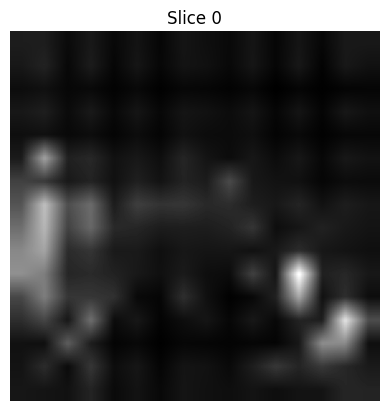

In [8]:
import matplotlib.pyplot as plt

plt.imshow(data[0], cmap="gray")
plt.title("Slice 0")
plt.axis("off")
plt.show()

Scroll through slices

In [17]:
%matplotlib widget

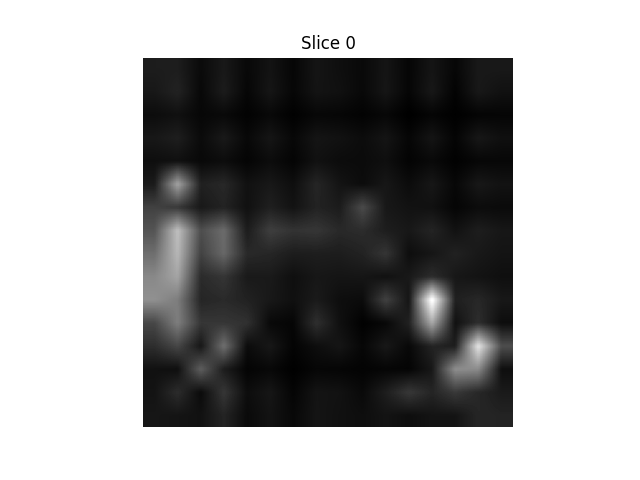

In [18]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

idx = 0
im = ax.imshow(data[idx], cmap="gray")
ax.set_title(f"Slice {idx}")
ax.axis("off")

def on_key(event):
    global idx
    if event.key == "right":
        idx = (idx + 1) % data.shape[0]
    elif event.key == "left":
        idx = (idx - 1) % data.shape[0]

    im.set_data(data[idx])
    ax.set_title(f"Slice {idx}")
    fig.canvas.draw_idle()

fig.canvas.mpl_connect("key_press_event", on_key)
plt.show()

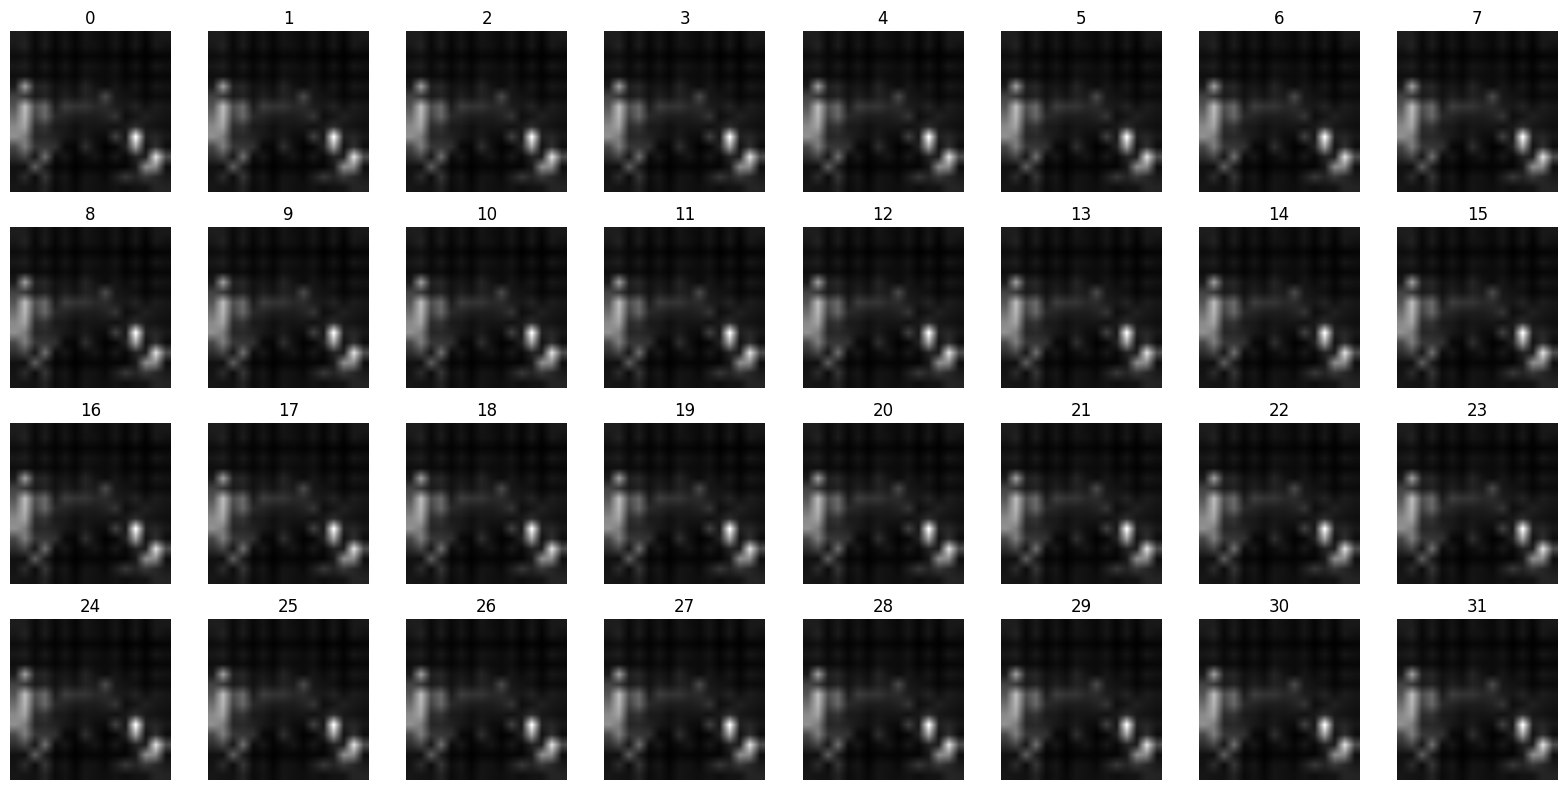

In [16]:
import matplotlib.pyplot as plt
import math

n = data.shape[0]
cols = 8
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 2*rows))

for i, ax in enumerate(axes.flat):
    if i < n:
        ax.imshow(data[i], cmap="gray")
        ax.set_title(i)
    ax.axis("off")

plt.tight_layout()
plt.show()

Are all slices exactly the same?

In [19]:
import numpy as np

all_equal = np.all(data == data[0])
print("All slices identical:", all_equal)

All slices identical: True


Find which slices differ

In [20]:
ref = data[0]
diff_slices = [i for i in range(data.shape[0]) if not np.allclose(data[i], ref, atol=1e-6)]
print("Different slices:", diff_slices)

Different slices: []
